# API Model Evaluation — Test Set Only

Runs the **same three pipeline strategies** (single-prompt, multi-hop, hybrid-RAG)  
against external API models and compares them to the FLAN-T5-XXL results.

**Models supported:**
- `openai`  → `gpt-3.5-turbo` (or any OpenAI chat model)
- `gemini`  → `gemini-2.5-flash` (or any Gemini model)

## 0. Environment

In [1]:
# Mount Google Drive (Colab only)
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Learning/UA_MSIS/Courses/10_CapstoneProject/MURA/fx_sentiment/

/content/drive/MyDrive/Learning/UA_MSIS/Courses/10_CapstoneProject/MURA/fx_sentiment


In [3]:
!pip install -q openai google-generativeai tqdm scikit-learn seaborn matplotlib pandas

## 1. API Keys & Model Selection

In [4]:
# ── Fill in your API keys ──────────────────────────────────────────────────────
OPENAI_API_KEY = "sk-..."  # OpenAI key
GEMINI_API_KEY = "AI..."  # Google AI Studio key

# ── Model strings (swap if you want a different variant) ──────────────────────
OPENAI_MODEL = "gpt-3.5-turbo"  # or "gpt-4o", "gpt-4-turbo", etc.
GEMINI_MODEL = "gemini-2.5-flash"  # or "gemini-1.5-pro", etc.

## 2. Load Test Data

In [5]:
import pandas as pd
from src.config import (
    TEST_PATH,
    LABEL_COL,
    TEXT_COL,
    TICKER_COL,
    IN_CONTEXT_COL,
    EX_CONTEXT_COLS,
)

df_test = pd.read_csv(TEST_PATH)
print(f"Test set: {len(df_test):,} rows")
df_test.head(2)

Test set: 462 rows


,published_at,ticker,true_sentiment,title,author,url,source,text,finbert_sentiment,finbert_sent_score,external_context_1,external_context_2,external_context_3
0,2023-01-12 10:34:00,EURCHF,Positive,EURCHF Trend higher may remain in place – ING,FXStreet Insights Team,https://www.fxstreet.com/news/eur-chf-trend-hi...,FX Street,EUR/CHF yesterday broke above 1.00. Economists...,Positive,0.51,European shares rise as investors await U.S. i...,CEE MARKETS-FX drifts before U.S. inflation da...,European shares rise as investors await U.S. i...
1,2023-01-14 19:48:00,EURCHF,Positive,EURCHF reaches 38.2% of the 2 year range as ru...,Greg Michalowski,https://www.forexlive.com/technical-analysis/e...,Forex Live,"The EURCHF is up for the 5th day in a row, aft...",Positive,0.91,Peloton Stock in 2023: Bull vs. Bear\n\nAfter ...,Nasdaq Bear Market: 5 Awe-Inspiring Growth Sto...,Nasdaq Bear Market: 5 Awe-Inspiring Growth Sto...


## 3. Shared Evaluation Helper

Reuses `src/pipelines.py` and `src/evaluation.py` as-is.

In [6]:
import importlib
import src.prompts
import src.inference
import src.pipelines

importlib.reload(src.prompts)
importlib.reload(src.inference)
importlib.reload(src.pipelines)

from tqdm import tqdm
import src.inference as inference
from src.pipelines import single_prompt_pipeline, multihop_pipeline, hybrid_rag_pipeline
from src.evaluation import evaluate


def run_all_strategies(df: pd.DataFrame, model_tag: str) -> dict:
    """
    Run all three strategies on df using whatever backend is currently active.
    Returns a dict of result DataFrames keyed by strategy name.
    """
    records_sp, records_mh, records_rag = [], [], []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=model_tag):
        title = row[TEXT_COL]
        ticker = row[TICKER_COL]
        label = row[LABEL_COL]
        in_ctx = row.get(IN_CONTEXT_COL, "")
        ex1 = row.get(EX_CONTEXT_COLS[0], "")
        ex2 = row.get(EX_CONTEXT_COLS[1], "")
        ex3 = row.get(EX_CONTEXT_COLS[2], "")

        base_row = {"title": title, "ticker": ticker, "true_sentiment": label}

        # Strategy 1 – single prompt
        out_sp = single_prompt_pipeline(title, ticker)
        records_sp.append({**base_row, "final_prediction": out_sp["final"]})

        # Strategy 2 – multi-hop
        out_mh = multihop_pipeline(title, ticker)
        records_mh.append(
            {
                **base_row,
                **{
                    "hop1_fx_insight": out_mh["hop1"],
                    "hop2_bc_sentiment": out_mh["hop2_bc"],
                    "hop3_qc_sentiment": out_mh["hop3_qc"],
                    "final_prediction": out_mh["final"],
                },
            }
        )

        # Strategy 3 – hybrid RAG
        out_rag = hybrid_rag_pipeline(title, ticker, in_ctx, ex1, ex2, ex3)
        records_rag.append(
            {
                **base_row,
                **{
                    "mode": out_rag["mode"],
                    "hop1_fx_insight": out_rag["hop1"],
                    "hop2_bc_sentiment": out_rag["hop2_bc"],
                    "hop3_qc_sentiment": out_rag["hop3_qc"],
                    "final_prediction": out_rag["final"],
                },
            }
        )

    return {
        "single_prompt": pd.DataFrame(records_sp),
        "multihop": pd.DataFrame(records_mh),
        "hybrid_rag": pd.DataFrame(records_rag),
    }

## 4. Run GPT-3.5-Turbo

Set backend to `openai`, then call the shared helper.

[inference] Backend set to 'openai'  model=gpt-3.5-turbo


GPT-3.5: 100%|██████████| 462/462 [33:55<00:00,  4.41s/it]



──────────────────────────────────────────────────
  GPT-3.5 / multihop — Test
──────────────────────────────────────────────────
  Accuracy  : 0.6710
  Macro F1  : 0.6554

              precision    recall  f1-score   support

    Positive     0.7815    0.7613    0.7712       155
     Neutral     0.6860    0.3598    0.4720       164
    Negative     0.5911    0.9301    0.7228       143

    accuracy                         0.6710       462
   macro avg     0.6862    0.6837    0.6554       462
weighted avg     0.6887    0.6710    0.6500       462



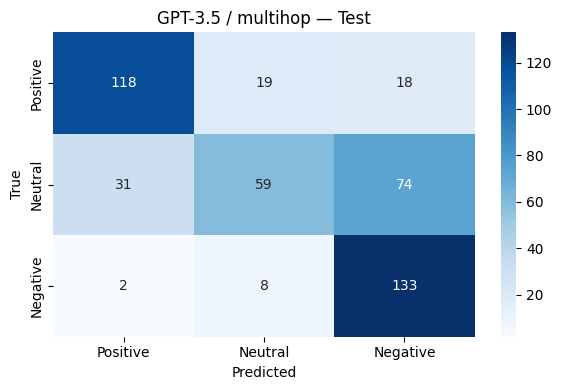


──────────────────────────────────────────────────
  GPT-3.5 / hybrid — Test
──────────────────────────────────────────────────
  Accuracy  : 0.7424
  Macro F1  : 0.7446

              precision    recall  f1-score   support

    Positive     0.8406    0.7484    0.7918       155
     Neutral     0.6750    0.6585    0.6667       164
    Negative     0.7256    0.8322    0.7752       143

    accuracy                         0.7424       462
   macro avg     0.7471    0.7464    0.7446       462
weighted avg     0.7462    0.7424    0.7423       462



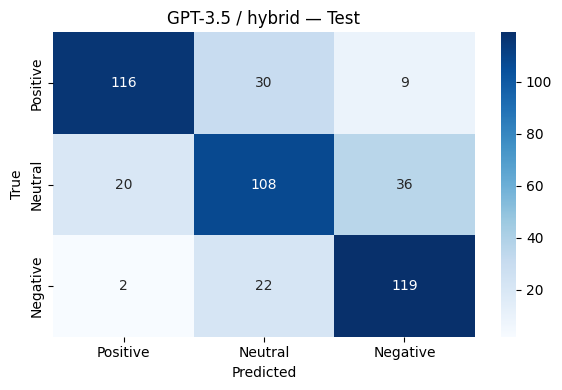


──────────────────────────────────────────────────
  GPT-3.5 / hybrid_rag — Test
──────────────────────────────────────────────────
  Accuracy  : 0.7446
  Macro F1  : 0.7468

              precision    recall  f1-score   support

    Positive     0.8507    0.7355    0.7889       155
     Neutral     0.6790    0.6707    0.6748       164
    Negative     0.7229    0.8392    0.7767       143

    accuracy                         0.7446       462
   macro avg     0.7509    0.7485    0.7468       462
weighted avg     0.7502    0.7446    0.7446       462



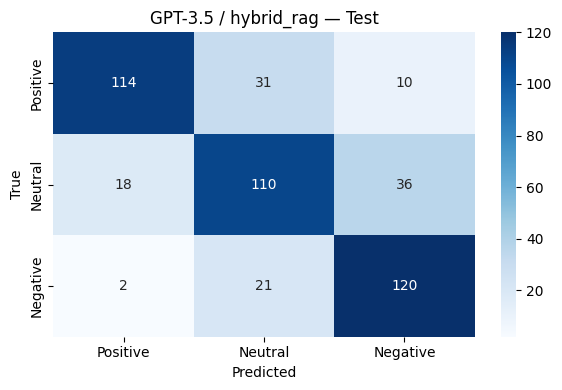

In [25]:
import time
from openai import RateLimitError

inference.set_backend("openai", model=OPENAI_MODEL, api_key=OPENAI_API_KEY)


def _safe_openai_call(fn, *args, **kwargs):
    for attempt in range(5):
        try:
            return fn(*args, **kwargs)
        except RateLimitError:
            wait = 2**attempt
            print(f"Rate limit hit, retrying in {wait}s... (attempt {attempt + 1}/5)")
            time.sleep(wait)
    return {
        "final": "Neutral",
        "hop1": None,
        "hop2_bc": None,
        "hop3_qc": None,
        "mode": "indirect",
    }


records_mh, records_hy, records_rag = [], [], []

for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc="GPT-3.5"):
    title = row[TEXT_COL]
    ticker = row[TICKER_COL]
    label = row[LABEL_COL]
    in_ctx = row.get(IN_CONTEXT_COL, "")
    ex1, ex2, ex3 = [row.get(c, "") for c in EX_CONTEXT_COLS]

    base_row = {"title": title, "ticker": ticker, "true_sentiment": label}

    out_mh = _safe_openai_call(multihop_pipeline, title, ticker)
    out_hy = _safe_openai_call(hybrid_rag_pipeline, title, ticker)
    out_rag = _safe_openai_call(
        hybrid_rag_pipeline, title, ticker, in_ctx, ex1, ex2, ex3
    )

    records_mh.append(
        {
            **base_row,
            "hop1_fx_insight": out_mh["hop1"],
            "hop2_bc_sentiment": out_mh["hop2_bc"],
            "hop3_qc_sentiment": out_mh["hop3_qc"],
            "final_prediction": out_mh["final"],
        }
    )
    records_hy.append(
        {
            **base_row,
            "mode": out_hy["mode"],
            "hop1_fx_insight": out_hy["hop1"],
            "hop2_bc_sentiment": out_hy["hop2_bc"],
            "hop3_qc_sentiment": out_hy["hop3_qc"],
            "final_prediction": out_hy["final"],
        }
    )
    records_rag.append(
        {
            **base_row,
            "mode": out_rag["mode"],
            "hop1_fx_insight": out_rag["hop1"],
            "hop2_bc_sentiment": out_rag["hop2_bc"],
            "hop3_qc_sentiment": out_rag["hop3_qc"],
            "final_prediction": out_rag["final"],
        }
    )

    time.sleep(0.5)

gpt_results = {
    "multihop": pd.DataFrame(records_mh),
    "hybrid": pd.DataFrame(records_hy),
    "hybrid_rag": pd.DataFrame(records_rag),
}

for strategy, df_res in gpt_results.items():
    tag = f"GPT-3.5 / {strategy} — Test"
    df_res.to_csv(f"data/finance/result_test_gpt35_{strategy}.csv", index=False)
    evaluate(df_res, title=tag)

## 5. Run Gemini 2.5 Flash

Swap backend to `gemini` — everything else is identical.

[inference] Backend set to 'gemini'  model=gemini-2.5-flash


Gemini-Flash:  47%|████▋     | 218/462 [57:18<1:08:58, 16.96s/it]

Gemini error: HTTPConnectionPool(host='localhost', port=33459): Read timed out. (read timeout=600.0), retrying in 1s... (attempt 1/5)


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1198791.90ms
Gemini-Flash: 100%|██████████| 462/462 [2:20:36<00:00, 18.26s/it]



──────────────────────────────────────────────────
  Gemini-Flash / multihop — Test
──────────────────────────────────────────────────
  Accuracy  : 0.6645
  Macro F1  : 0.6536

              precision    recall  f1-score   support

    Positive     0.8015    0.6774    0.7343       155
     Neutral     0.9000    0.3841    0.5385       164
    Negative     0.5326    0.9720    0.6881       143

    accuracy                         0.6645       462
   macro avg     0.7447    0.6779    0.6536       462
weighted avg     0.7532    0.6645    0.6505       462



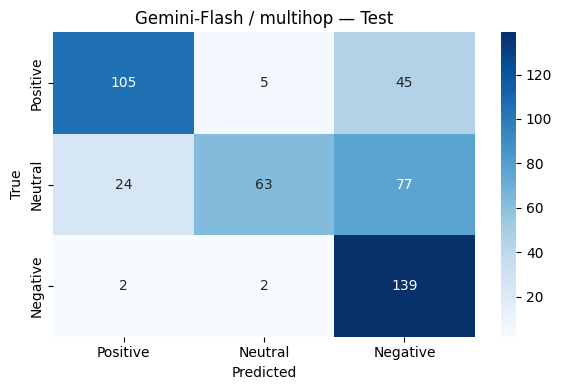


──────────────────────────────────────────────────
  Gemini-Flash / hybrid — Test
──────────────────────────────────────────────────
  Accuracy  : 0.7251
  Macro F1  : 0.7230

              precision    recall  f1-score   support

    Positive     0.8846    0.7419    0.8070       155
     Neutral     0.7373    0.5305    0.6170       164
    Negative     0.6215    0.9301    0.7451       143

    accuracy                         0.7251       462
   macro avg     0.7478    0.7342    0.7230       462
weighted avg     0.7509    0.7251    0.7204       462



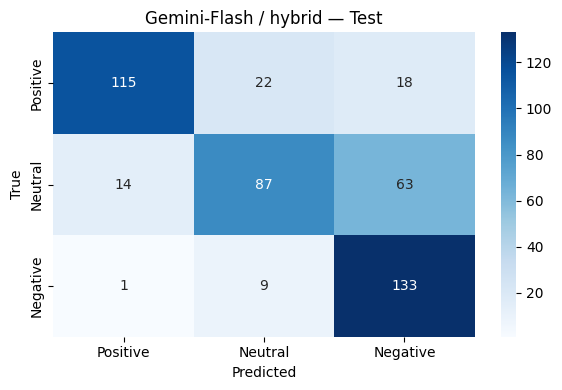


──────────────────────────────────────────────────
  Gemini-Flash / hybrid_rag — Test
──────────────────────────────────────────────────
  Accuracy  : 0.7338
  Macro F1  : 0.7317

              precision    recall  f1-score   support

    Positive     0.8855    0.7484    0.8112       155
     Neutral     0.7355    0.5427    0.6246       164
    Negative     0.6381    0.9371    0.7592       143

    accuracy                         0.7338       462
   macro avg     0.7530    0.7427    0.7317       462
weighted avg     0.7557    0.7338    0.7289       462



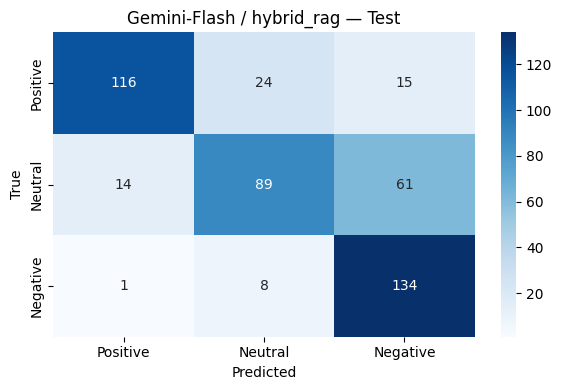

In [26]:
import time

inference.set_backend("gemini", model=GEMINI_MODEL, api_key=GEMINI_API_KEY)


def _safe_gemini_call(fn, *args, **kwargs):
    for attempt in range(5):
        try:
            return fn(*args, **kwargs)
        except Exception as e:
            wait = 2**attempt
            print(
                f"Gemini error: {e}, retrying in {wait}s... (attempt {attempt + 1}/5)"
            )
            time.sleep(wait)
    return {
        "final": "Neutral",
        "hop1": None,
        "hop2_bc": None,
        "hop3_qc": None,
        "mode": "indirect",
    }


records_mh, records_hy, records_rag = [], [], []

for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc="Gemini-Flash"):
    title = row[TEXT_COL]
    ticker = row[TICKER_COL]
    label = row[LABEL_COL]
    in_ctx = row.get(IN_CONTEXT_COL, "")
    ex1, ex2, ex3 = [row.get(c, "") for c in EX_CONTEXT_COLS]

    base_row = {"title": title, "ticker": ticker, "true_sentiment": label}

    out_mh = _safe_gemini_call(multihop_pipeline, title, ticker)
    out_hy = _safe_gemini_call(hybrid_rag_pipeline, title, ticker)
    out_rag = _safe_gemini_call(
        hybrid_rag_pipeline, title, ticker, in_ctx, ex1, ex2, ex3
    )

    records_mh.append(
        {
            **base_row,
            "hop1_fx_insight": out_mh["hop1"],
            "hop2_bc_sentiment": out_mh["hop2_bc"],
            "hop3_qc_sentiment": out_mh["hop3_qc"],
            "final_prediction": out_mh["final"],
        }
    )
    records_hy.append(
        {
            **base_row,
            "mode": out_hy["mode"],
            "hop1_fx_insight": out_hy["hop1"],
            "hop2_bc_sentiment": out_hy["hop2_bc"],
            "hop3_qc_sentiment": out_hy["hop3_qc"],
            "final_prediction": out_hy["final"],
        }
    )
    records_rag.append(
        {
            **base_row,
            "mode": out_rag["mode"],
            "hop1_fx_insight": out_rag["hop1"],
            "hop2_bc_sentiment": out_rag["hop2_bc"],
            "hop3_qc_sentiment": out_rag["hop3_qc"],
            "final_prediction": out_rag["final"],
        }
    )

    time.sleep(4)  # free tier: 15 RPM, each row ~3 calls so 4s keeps safely under limit

gemini_results = {
    "multihop": pd.DataFrame(records_mh),
    "hybrid": pd.DataFrame(records_hy),
    "hybrid_rag": pd.DataFrame(records_rag),
}

for strategy, df_res in gemini_results.items():
    tag = f"Gemini-Flash / {strategy} — Test"
    df_res.to_csv(f"data/finance/result_test_gemini_flash_{strategy}.csv", index=False)
    evaluate(df_res, title=tag)

## 6. Cross-Model Comparison

In [11]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

flan_files = {
    "FLAN-T5 / multihop": "data/finance/result_test_multihop.csv",
    "FLAN-T5 / hybrid": "data/finance/result_test_hybrid.csv",
    "FLAN-T5 / hybrid_rag": "data/finance/result_test_hybrid_RAG.csv",
}

gpt_files = {
    "GPT-3.5 / multihop": "data/finance/result_test_gpt35_multihop.csv",
    "GPT-3.5 / hybrid": "data/finance/result_test_gpt35_hybrid.csv",
    "GPT-3.5 / hybrid_rag": "data/finance/result_test_gpt35_hybrid_rag.csv",
}

gemini_files = {
    "Gemini-Flash / multihop": "data/finance/result_test_gemini_flash_multihop.csv",
    "Gemini-Flash / hybrid": "data/finance/result_test_gemini_flash_hybrid.csv",
    "Gemini-Flash / hybrid_rag": "data/finance/result_test_gemini_flash_hybrid_rag.csv",
}

all_results = []

for group in [flan_files, gpt_files, gemini_files]:
    for name, path in group.items():
        try:
            df = pd.read_csv(path)
            acc = accuracy_score(df[LABEL_COL], df["final_prediction"])
            f1 = f1_score(
                df[LABEL_COL], df["final_prediction"], average="macro", zero_division=0
            )
            all_results.append(
                {
                    "Model / Strategy": name,
                    "Accuracy": round(acc, 4),
                    "Macro F1": round(f1, 4),
                }
            )
        except FileNotFoundError:
            print(f"⚠  Skipped (file not found): {path}")

summary = pd.DataFrame(all_results)
print("Result summary in Test Set")
print(summary.to_string(index=False))
summary.to_csv("data/finance/comparison_all_models.csv", index=False)

Result summary in Test Set
         Model / Strategy  Accuracy  Macro F1
       FLAN-T5 / multihop    0.7641    0.7616
         FLAN-T5 / hybrid    0.7706    0.7686
     FLAN-T5 / hybrid_rag    0.7684    0.7669
       GPT-3.5 / multihop    0.6710    0.6554
         GPT-3.5 / hybrid    0.7424    0.7446
     GPT-3.5 / hybrid_rag    0.7446    0.7468
  Gemini-Flash / multihop    0.6645    0.6536
    Gemini-Flash / hybrid    0.7251    0.7230
Gemini-Flash / hybrid_rag    0.7338    0.7317
